In [1]:
import gseapy as gp

import scanpy as sc
import os, sys
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import pickle
import seaborn as sns

import re




In [2]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


In [3]:
import pickle

with open('eczema_tdc_mcp_top200.pkl', 'rb') as f:
    gene_programme200 = pickle.load(f)

print(gene_programme200)



['CD3E', 'CXCR4', 'CYBA', 'CD4', 'CCR4', 'ITGB2', 'ADAM8', 'TNFRSF1B', 'PLEC', 'JAK3', 'IL2RG', 'FSCN1', 'CD5', 'SELPLG', 'ACAP1', 'ITGAL', 'IKZF1', 'CD247', 'CD83', 'CCL22', 'CCR7', 'CCL17', 'MYH9', 'RUNX3', 'CFLAR', 'BATF', 'ZAP70', 'LAMP3', 'ALOX15', 'UCP2', 'FOXP3', 'SEPTIN9', 'CCL19', 'GRK2', 'MIAT', 'CD6', 'TNFRSF18', 'IKZF3', 'TCF7', 'PIM2', 'IL21R', 'CTLA4', 'CD7', 'MSN', 'SLC2A3', 'TRAF1', 'RFTN1', 'FURIN', 'SH2D2A', 'SERPINB9', 'IL2RB', 'IRF4', 'IL2RA', 'RASGRP1', 'CD96', 'CSF2RB', 'CD27', 'TAP1', 'TUBB', 'TMEM173', 'ZYX', 'CD1B', 'CD8A', 'GIMAP5', 'CLEC10A', 'CDKN1A', 'CD44', 'TIGIT', 'IRF1', 'CD1E', 'CTSH', 'CST7', 'MMP9', 'ARF6', 'PKM', 'KCNN4', 'PPP1CA', 'CSF2RA', 'SPI1', 'CD40LG', 'CFP', 'HNRNPH1', 'MMP12', 'ADAM12', 'CIITA', 'PFKFB3', 'PGK1', 'CD274', 'FLII', 'HSPA8', 'TNFRSF9', 'LMNB1', 'NR4A3', 'DUSP5', 'WDFY4', 'HCK', 'CD1C', 'CXCR3', 'SND1', 'CD99', 'EBI3', 'PRDM1', 'TUBB2B', 'CD1A', 'XBP1', 'CPVL', 'MCM5', 'CTBP1', 'TENT5C', 'ADAR', 'SF3A1', 'FCER1A', 'CCAR2', 'SOR

In [4]:
gsea_results = []

gene_list = gene_programme200
enr = gp.enrichr(gene_list=gene_list[:100],
                 gene_sets='GO_Biological_Process_2023',   
                 outdir=None,  
                 cutoff=0.05  # Cutoff for statistical significance
                )
#enr.results['Cluster'] = cluster
gsea_results.append(enr.results)

gsea_df = pd.concat(gsea_results)
gsea_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,T Cell Activation (GO:0042110),14/111,3.356784e-16,3.759598e-13,0,0,33.234476,1184.156952,MSN;CD1C;CD3E;FOXP3;RASGRP1;ZAP70;CD4;CD8A;IRF...
1,GO_Biological_Process_2023,Cellular Response To Cytokine Stimulus (GO:007...,17/308,2.084114e-13,1.167104e-10,0,0,13.801722,403.000111,CCL22;SELPLG;TCF7;ALOX15;CXCR4;CSF2RB;IL2RG;CS...
2,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),15/236,7.979324e-13,2.978948e-10,0,0,15.713867,437.737317,CD96;CIITA;CCL22;ALOX15;ITGB2;CXCR4;CYBA;ITGAL...
3,GO_Biological_Process_2023,Cytokine-Mediated Signaling Pathway (GO:0019221),15/257,2.735510e-12,7.659427e-10,0,0,14.334954,381.663893,SPI1;CCL22;CSF2RB;TRAF1;IL2RG;TNFRSF1B;CSF2RA;...
4,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,13/320,7.207406e-09,1.614459e-06,0,0,9.536448,178.790828,CD274;RFTN1;CYBA;RASGRP1;BATF;CD4;CD40LG;CD6;I...
...,...,...,...,...,...,...,...,...,...,...
1115,GO_Biological_Process_2023,Positive Regulation Of Cell Differentiation (G...,1/283,7.603718e-01,7.630971e-01,0,0,0.702701,0.192503,ADAM8
1116,GO_Biological_Process_2023,DNA Metabolic Process (GO:0006259),1/288,7.663877e-01,7.684460e-01,0,0,0.690283,0.183662,FSCN1
1117,GO_Biological_Process_2023,DNA Repair (GO:0006281),1/291,7.699252e-01,7.713025e-01,0,0,0.683037,0.178588,FSCN1
1118,GO_Biological_Process_2023,Regulation Of Intracellular Signal Transductio...,1/297,7.768420e-01,7.775362e-01,0,0,0.668987,0.168932,TRAF1


# gene programme

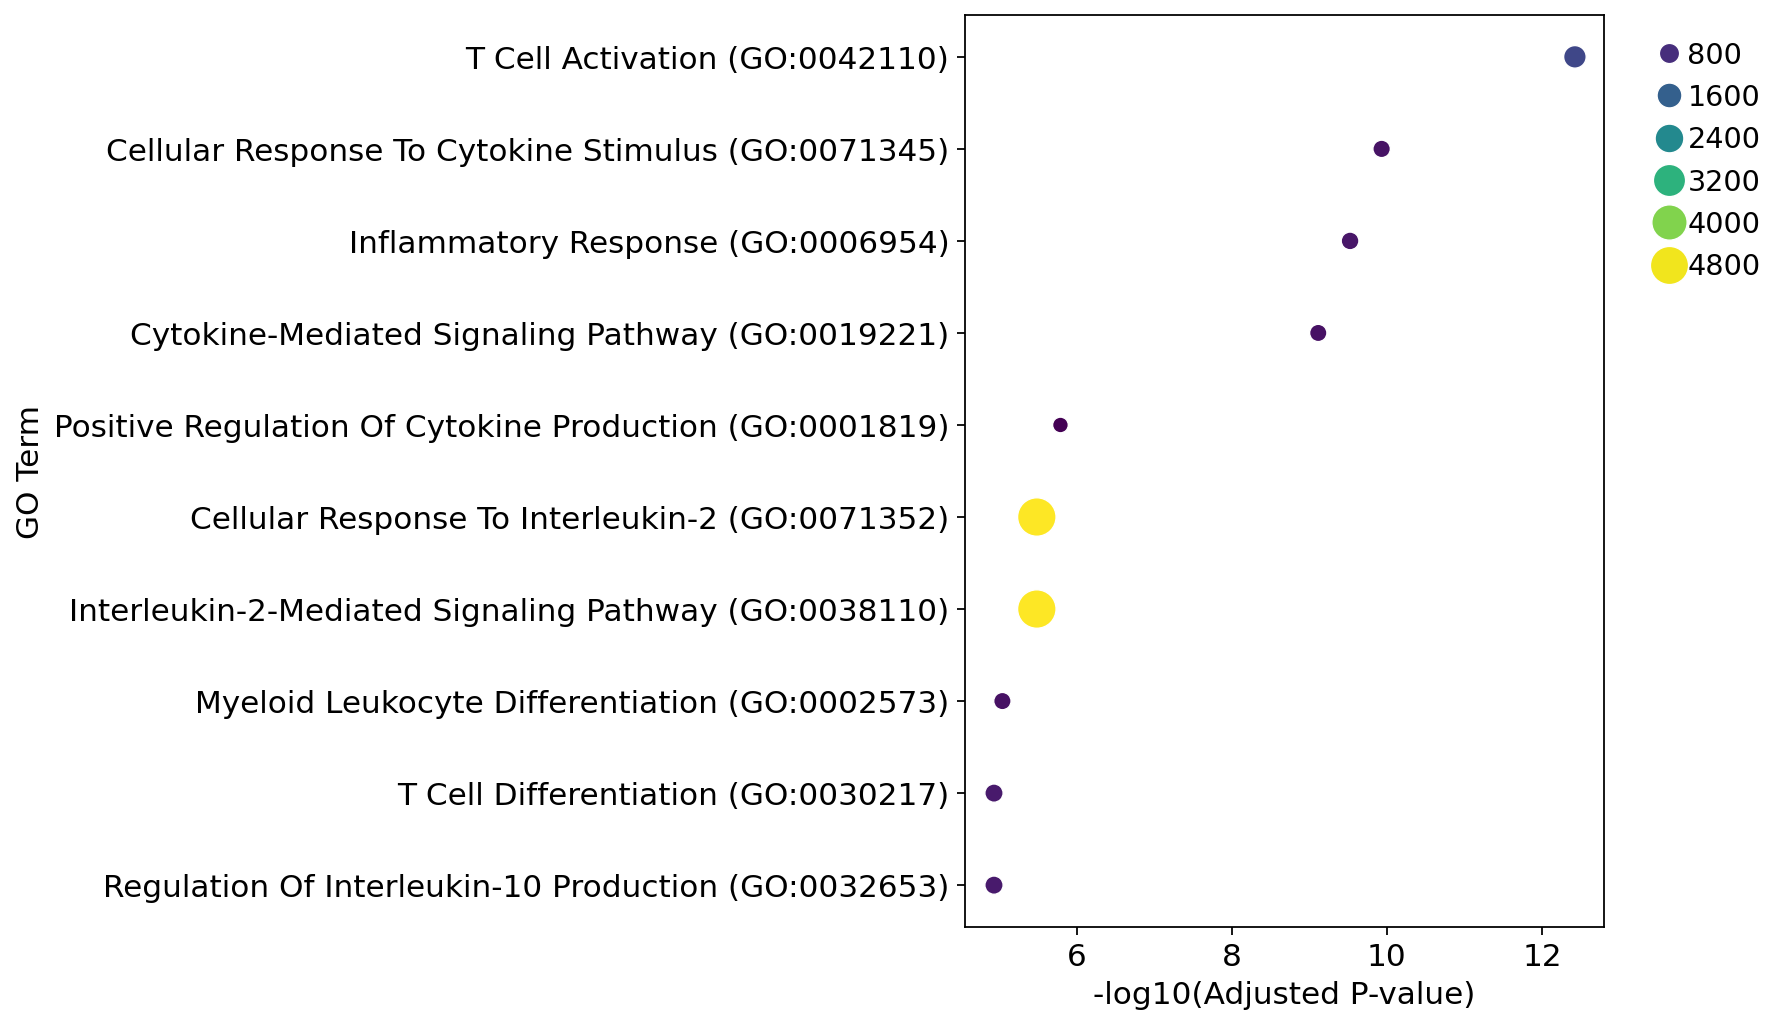

In [5]:
# Assuming gsea_df exists already
top_n = 10  # adjust as needed
gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n)

# Calculate -log10(padj)
gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)  # NOTE the negative sign here!
)

# Sort so most significant (highest -log10) are at top
gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=False)

# Plot
plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=gsea_df_sorted,
    x='-log10(padj)',
    y='Term',
    size='Combined Score',
    hue='Combined Score',
    palette='viridis',
    sizes=(50, 300),
    legend='brief'
)

# 1) Move legend to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# 2) Remove box around legend → already done with frameon=False

# 3) Remove the title
# (Just don't set any title)

# 4) Remove background grid
ax.grid(False)

# 5) Fix cut-off circles
plt.tight_layout(pad=2)

# 6) Most significant terms at top → done via sorting above

# Final clean-up
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('GO Term')

plt.show()


# perturbed genes

In [6]:
sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.grid'] = False


# pertubation 2 - fig 3f

In [7]:
PERTURB2_MIGDC = ['TRPM4', 'CDC37', 'TUBB', 'NR1H2', 'GRN', 'PARM1', 'RAC1', 'TMEM97', 'VDAC2', 'RHOA', 'NPR1', 'TAP1', 'PKM', 'YWHAQ', 'DDX6', 'NFE2L2', 'CSF2RB', 'CSNK2A1', 'F11R', 'ATF4']

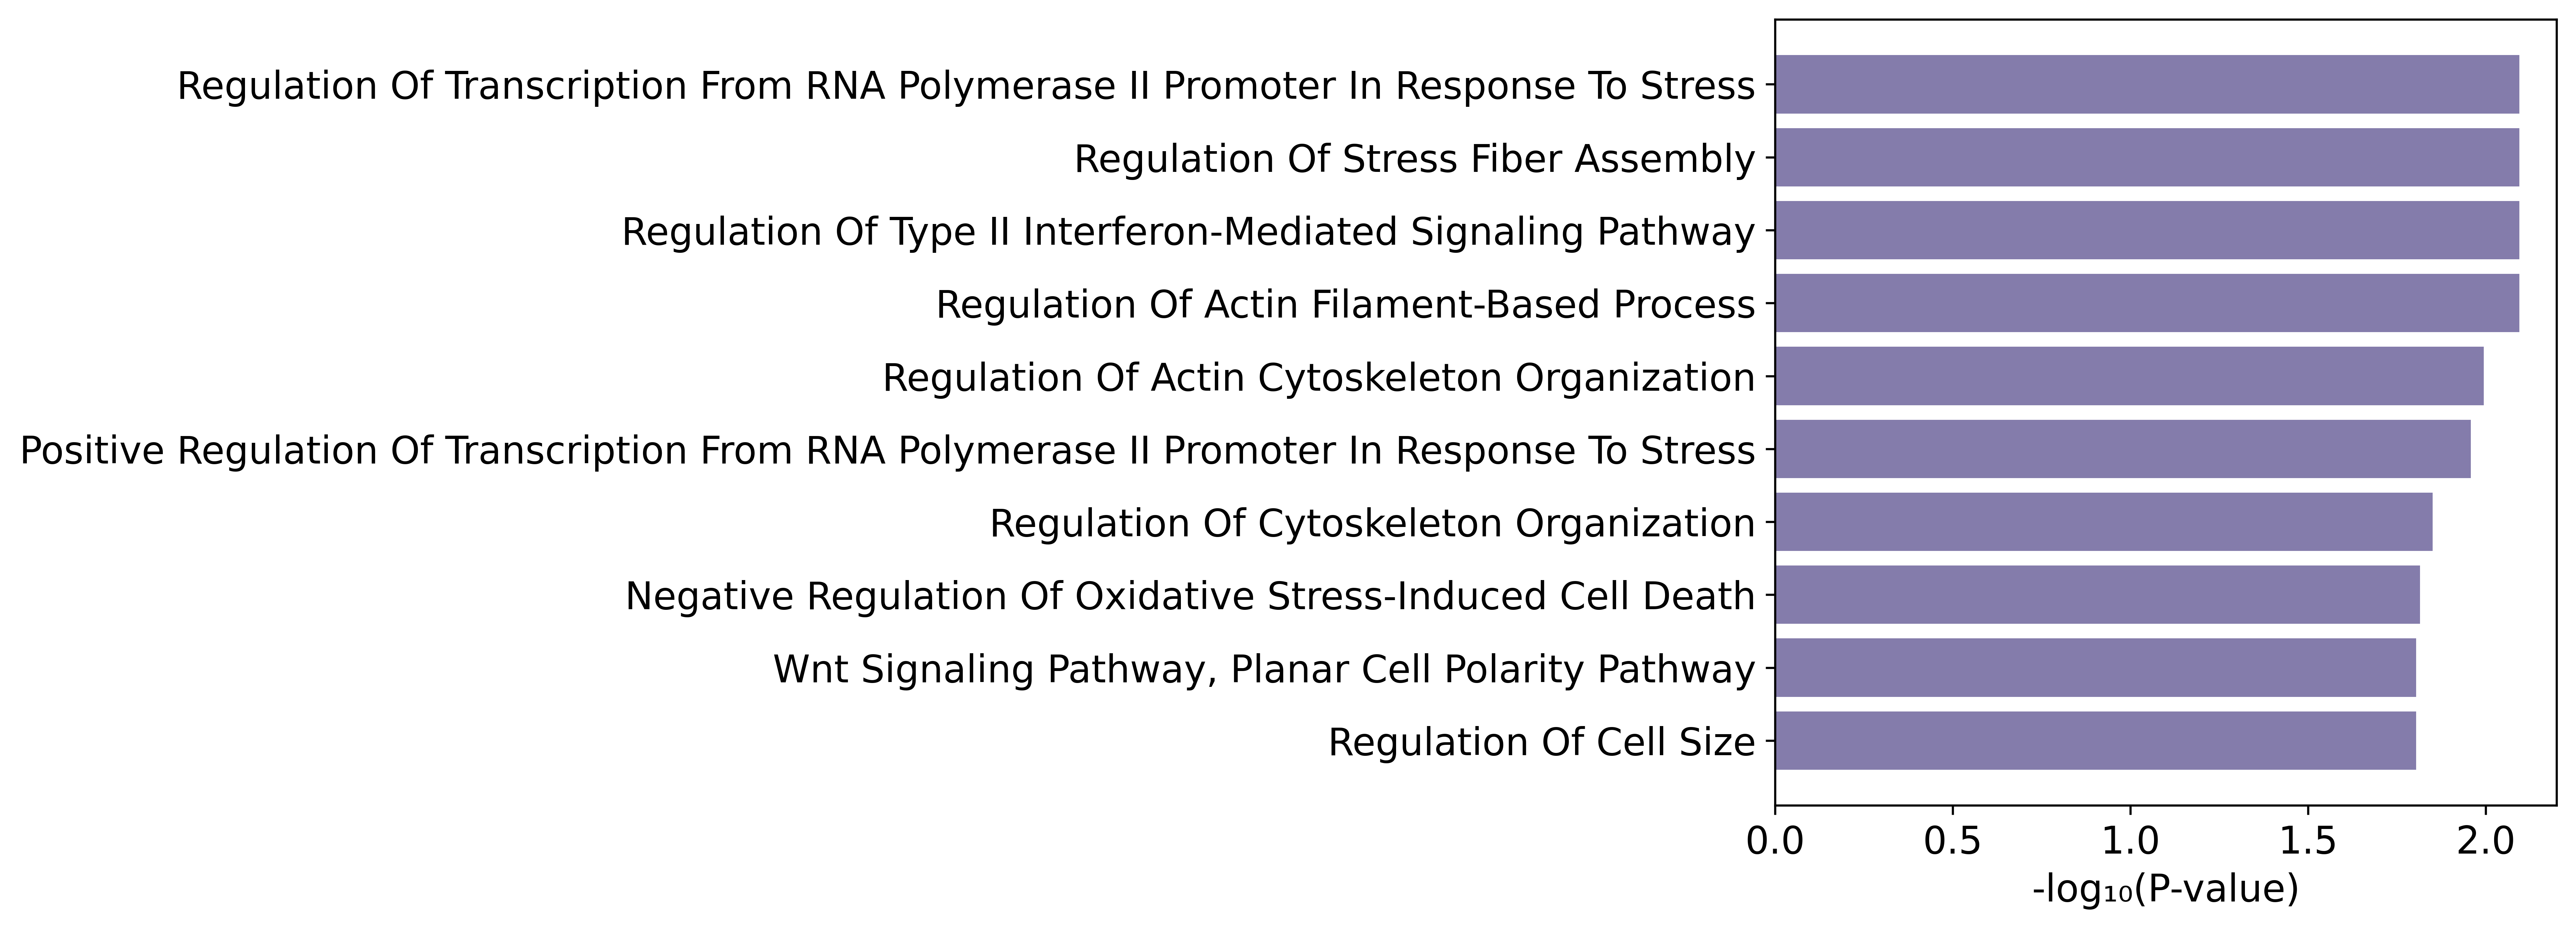

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

top_n = 10
gsea_results = []

enr = gp.enrichr(
    gene_list=PERTURB2_MIGDC,
    gene_sets='GO_Biological_Process_2023',
    outdir=None,
    cutoff=0.05
)

gsea_results.append(enr.results)
gsea_df = pd.concat(gsea_results)

gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n).copy()

gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)
)

gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)

gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

fig, ax = plt.subplots(figsize=(13.5, 5))

ax.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#847cab'
)

ax.set_xlabel('-log₁₀(P-value)')
ax.set_ylabel('')

plt.tight_layout()

# ---- save at 300 dpi ----
fig.savefig(
    "migdc_p3.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

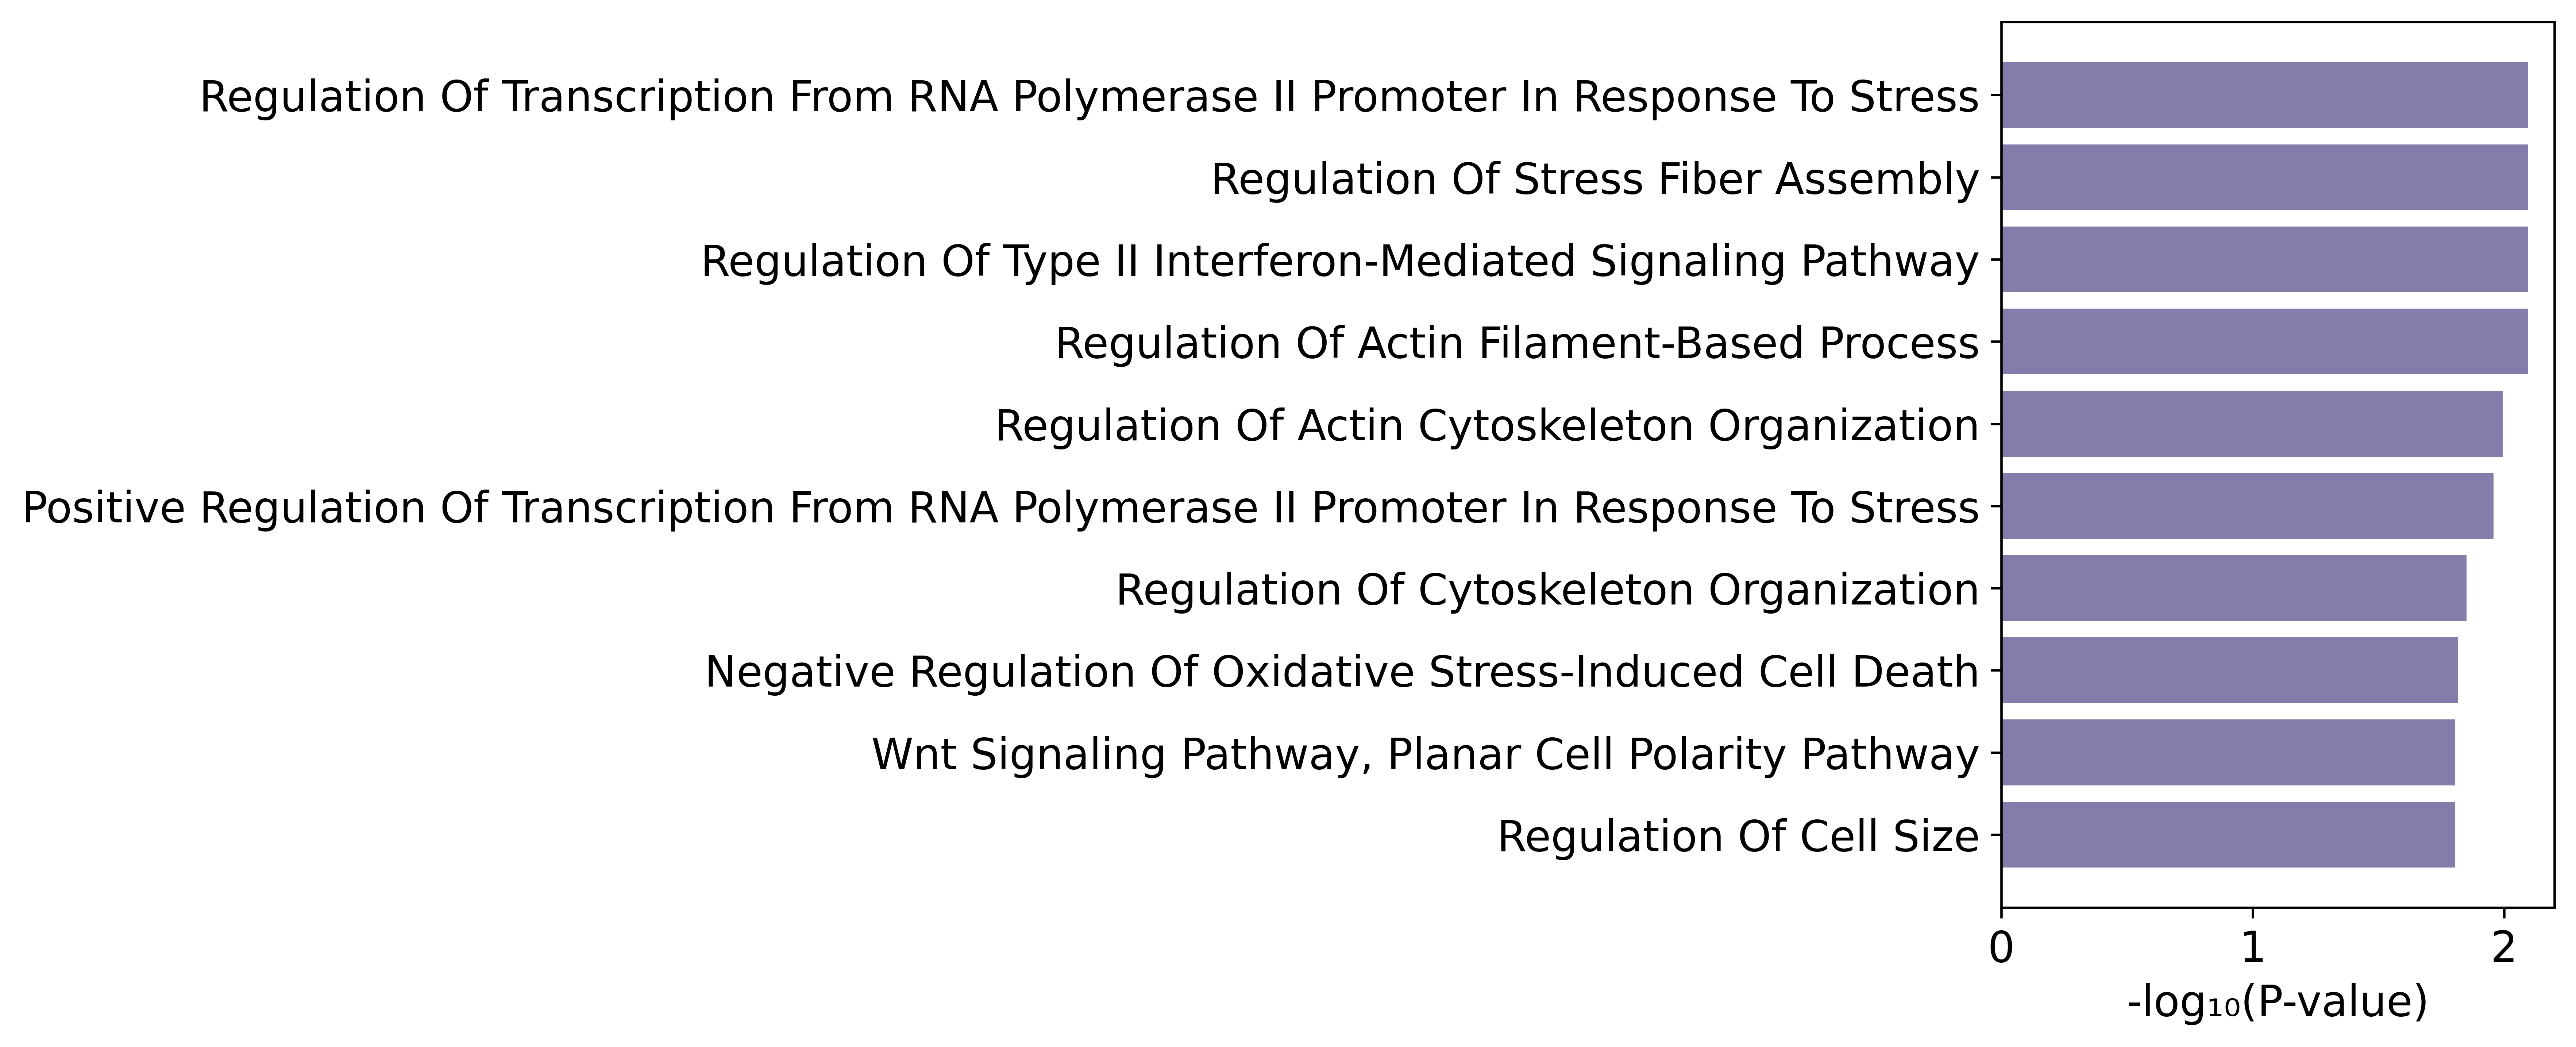

In [9]:
top_n = 10 
gsea_results = []

#gene_list = genes0
enr = gp.enrichr(gene_list=PERTURB2_MIGDC,
                 gene_sets='GO_Biological_Process_2023',   
                 outdir=None,  
                 cutoff=0.05  # Cutoff for statistical significance
                )
gsea_results.append(enr.results)
gsea_df = pd.concat(gsea_results)

gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n).copy()

gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)
)

gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)

gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

plt.figure(figsize=(12, 5))
plt.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#847cab'
)
plt.xlabel('-log₁₀(P-value)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Treg depletion (perturbation 1) - fig  3d

In [11]:
PERTURB1_T = ['ADAM8', 'PFKFB3', 'ITGB2', 'YWHAZ', 'IL2RA', 'FOXP3', 
              'CD247', 'TNFRSF18', 'HPGD', 'CD96', 'CXCR4', 'CD4', 'BATF', 'IL2RB', 'RASGRP1', 'PRDM1', 'IKZF3', 'IKZF1', 'ZAP70', 'WDR26']


In [12]:
gsea_results = []

enr = gp.enrichr(gene_list=PERTURB1_T,
                 gene_sets='GO_Biological_Process_2023',   
                 outdir=None,  
                 cutoff=0.05  # Cutoff for statistical significance
                )
gsea_results.append(enr.results)

gsea_df = pd.concat(gsea_results)

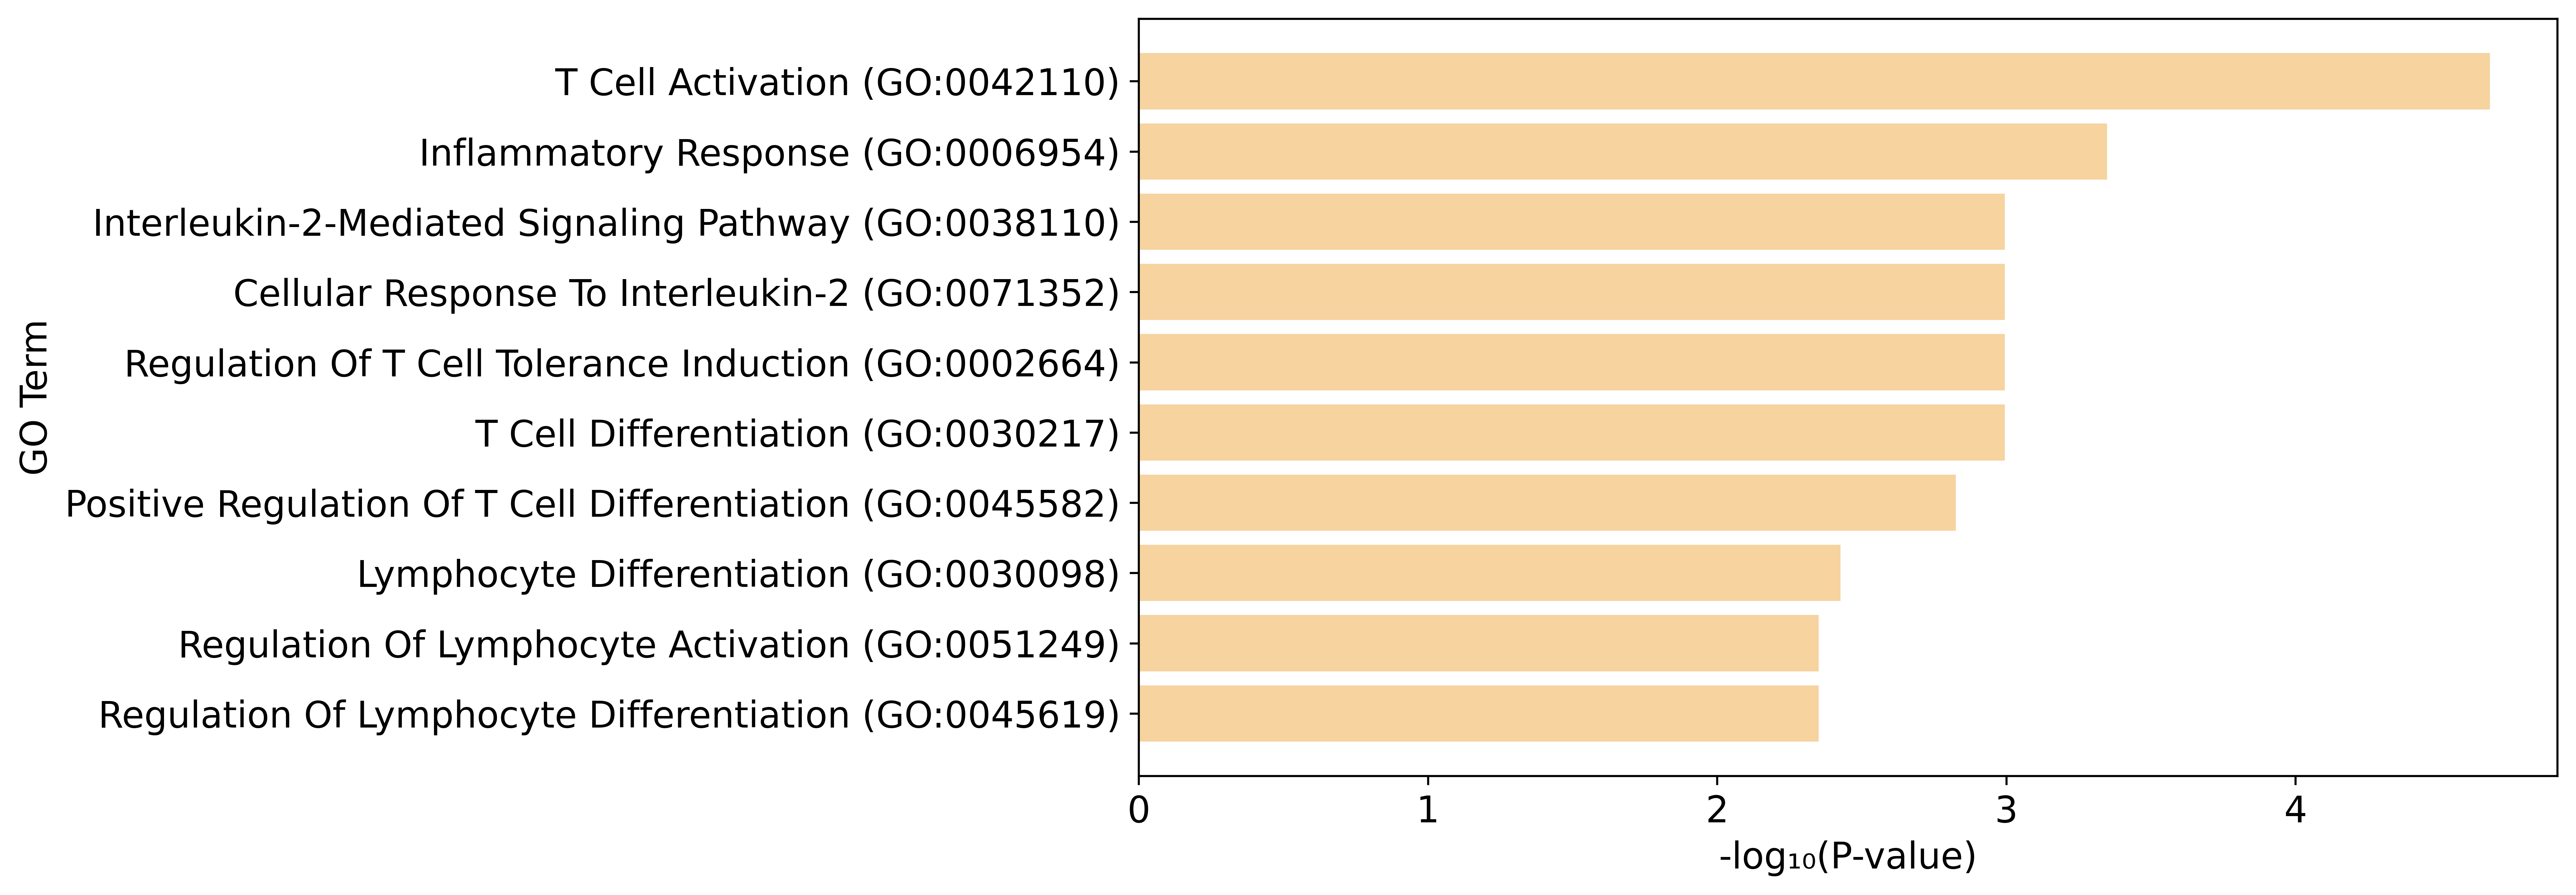

In [13]:
top_n = 10
gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n).copy()

gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)
)

gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)

plt.figure(figsize=(14, 5))
bars = plt.barh(
    y=gsea_df_sorted['Term'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#f6d39f'
)

plt.xlabel('-log₁₀(P-value)')
plt.ylabel('GO Term')


plt.grid(False)

plt.tight_layout()
plt.show()

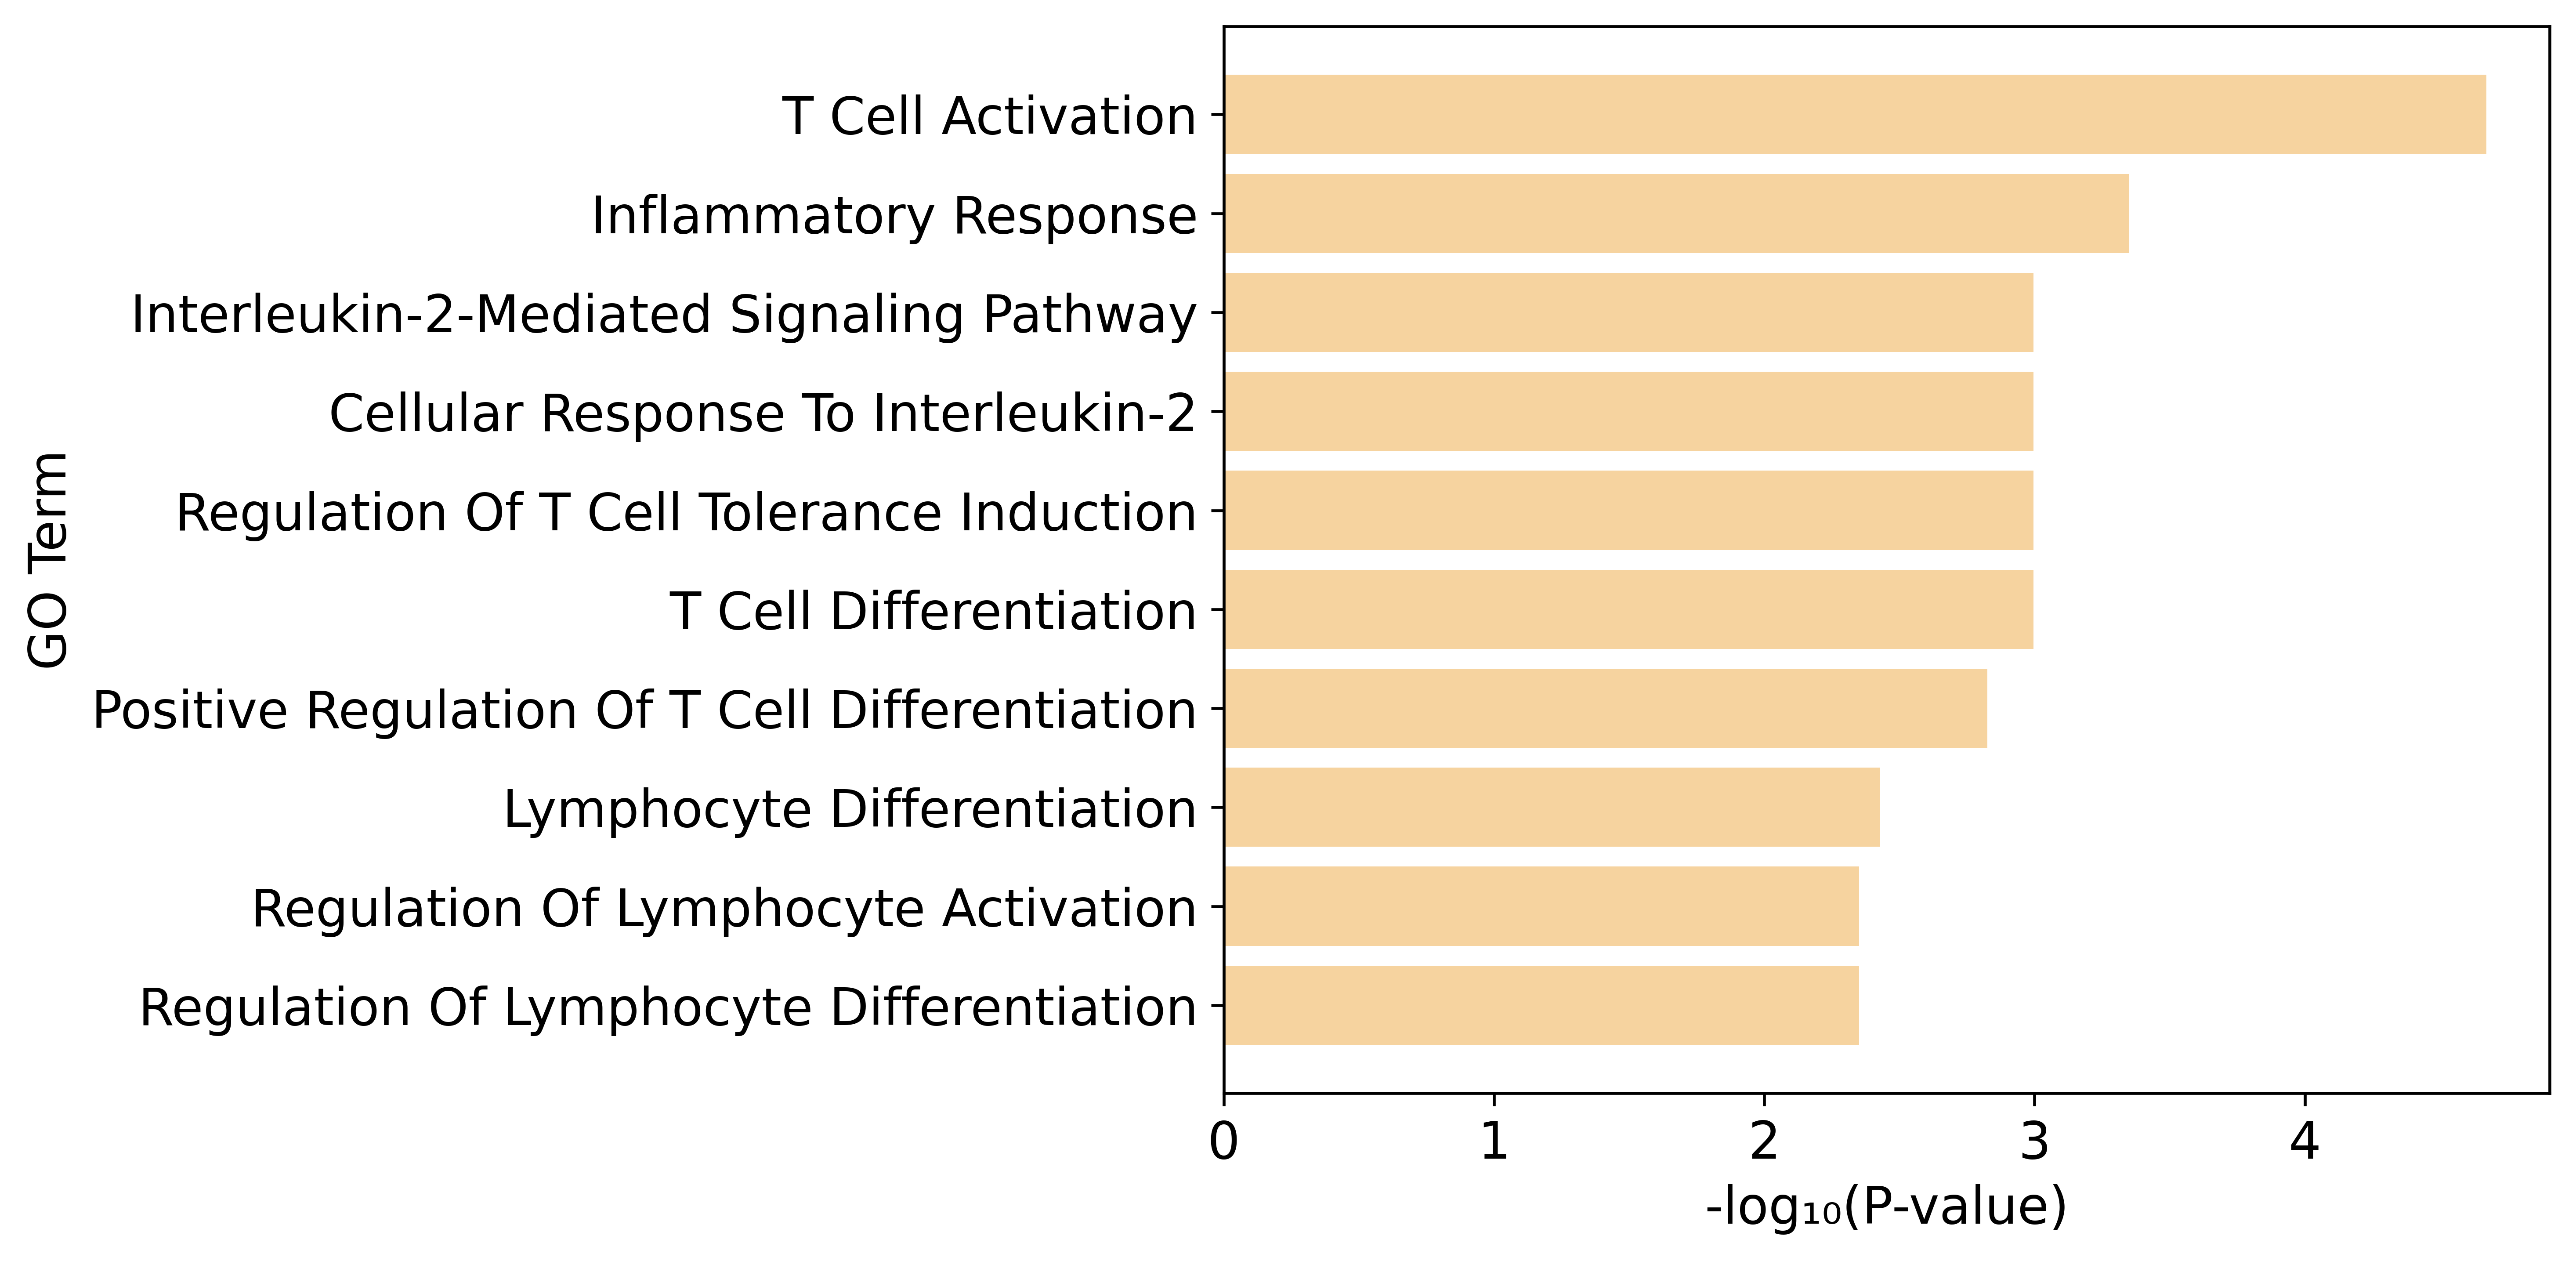

In [14]:
import re

gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

plt.figure(figsize=(10, 5))
plt.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#f6d39f'
)
plt.xlabel('-log₁₀(P-value)')
plt.ylabel('GO Term')
plt.tight_layout()
plt.show()

In [15]:
PERTURB1_MIGDC = ['CCL22', 'ADAM8', 'PLEC', 'FCGBP', 'IL2RA', 'WDFY4', 'PFKFB3', 'CD83', 'CCL17', 'CD207', 'CLEC10A', 'CD4', 'MMP9', 'LAMP3', 'HSPD1', 'ALOX15', 'CCR7', 'CD1C', 'ITGB2', 'CD44']


In [16]:
gsea_results = []

enr = gp.enrichr(gene_list=PERTURB1_MIGDC,
                 gene_sets='GO_Biological_Process_2023',   
                 outdir=None,  
                 cutoff=0.05  # Cutoff for statistical significance
                )
#enr.results['Cluster'] = cluster
gsea_results.append(enr.results)

gsea_df = pd.concat(gsea_results)

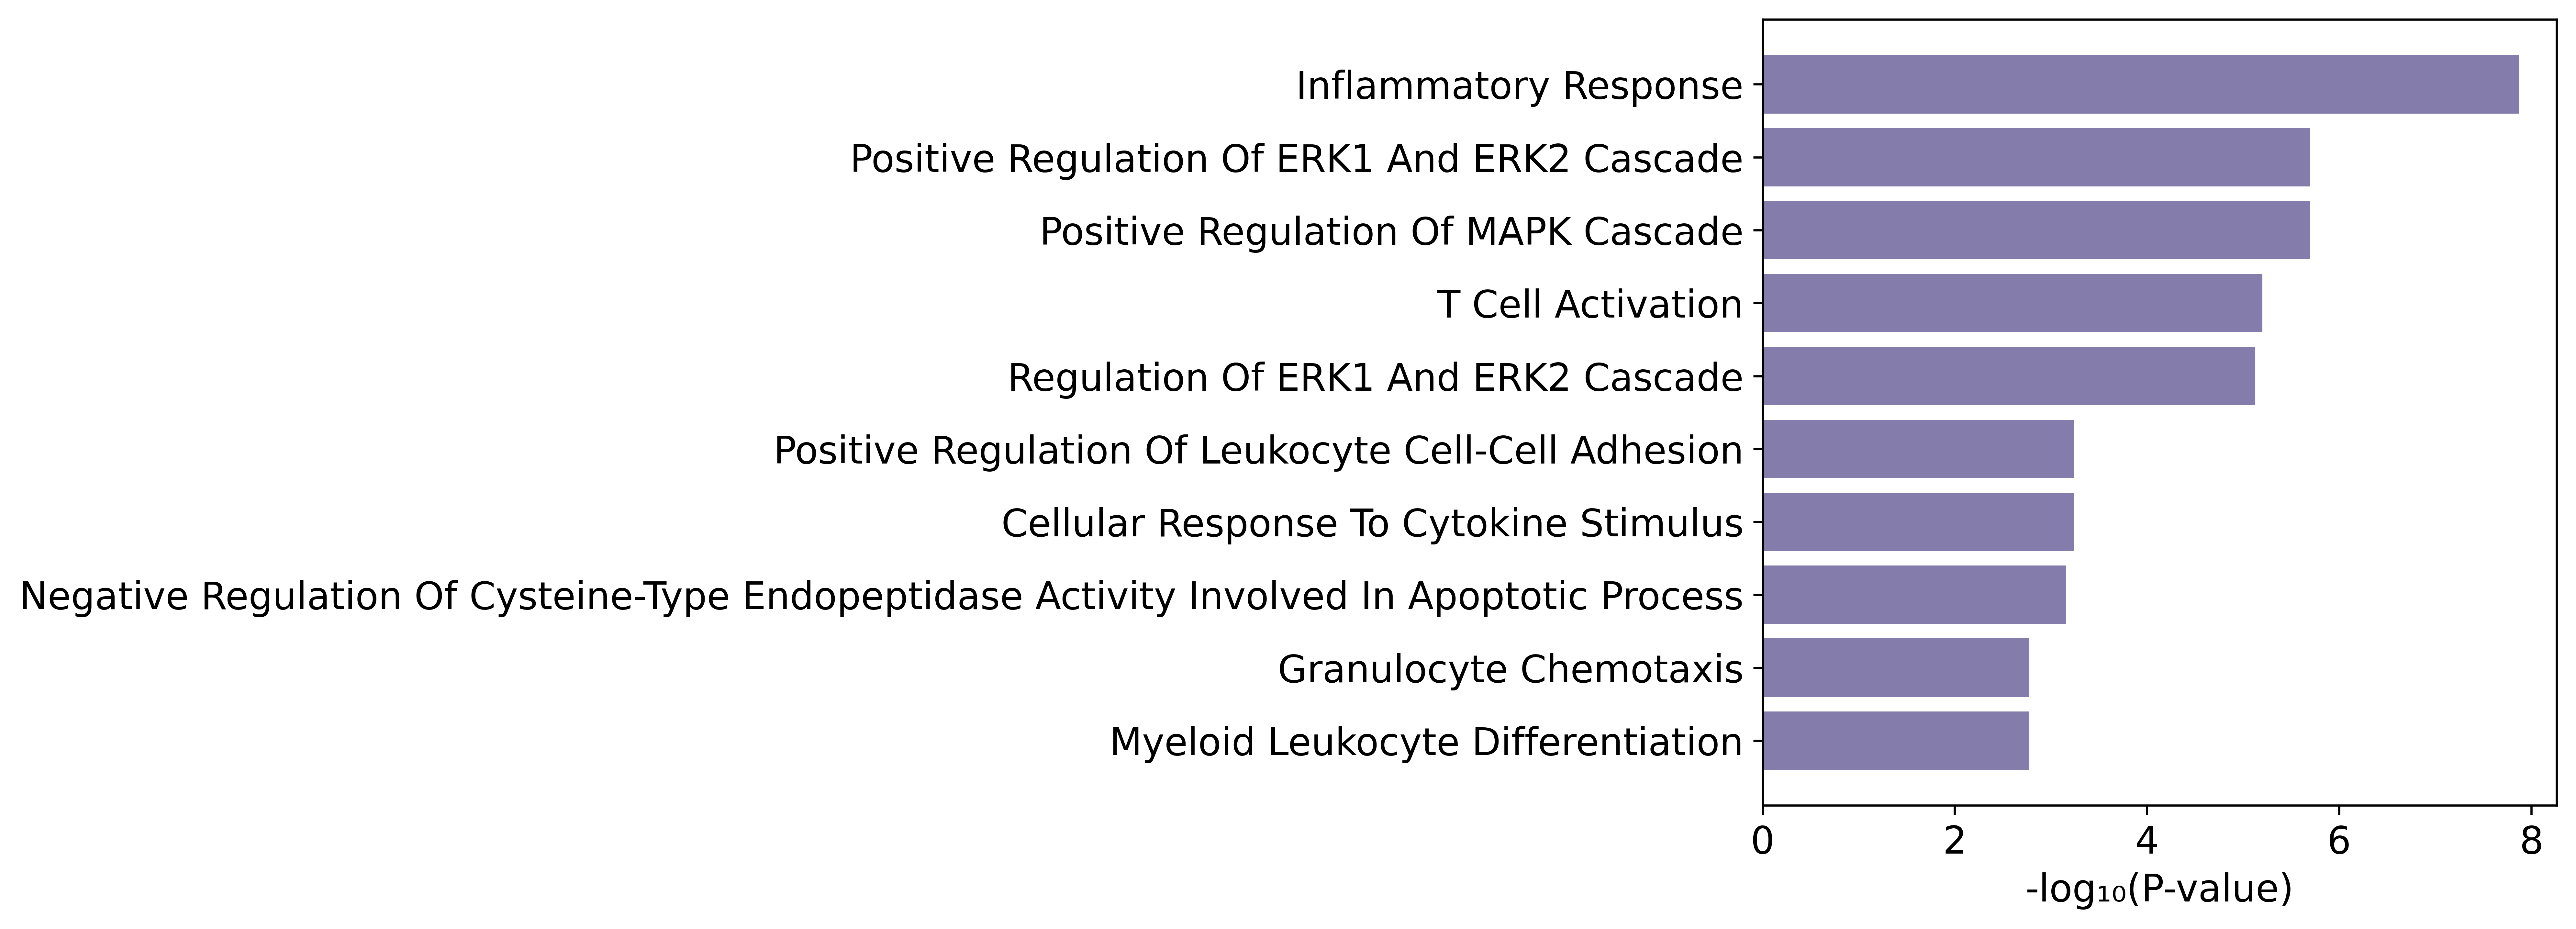

In [17]:
top_n = 10
gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n).copy()

gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)
)

gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)


gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

plt.figure(figsize=(13.5, 5))
plt.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#847cab'
)
plt.xlabel('-log₁₀(P-value)')
plt.ylabel('')
plt.tight_layout()
plt.show()